## check coordinates in netcdf file and mask

- Unfortunately, there are no geographical coordinates in the metadata of the cci lake dataset (https://doi.org/10.1038/s41597-022-01889-z)
- However, there is a script distributed for downloading `netcdf` files in a jupyter notebook (an official one) here: https://github.com/cci-lakes/lakes_cci_tools/blob/main/lakes_cci_binder.ipynb. 
- This uses a mask file (`ESA_CCI_static_lake_mask_v2.0.1.nc` in this folder), where the id of a lake (which can be looked up in the file `lakescci_v2.1.0_metadata.csv` in this folder) is used to download a netcdf file for the lake of interest
    - in this csv file are also the min max lon and lat values as well as centroids of the box of the lakes stored
- one can also get the bonding box of the lake that is used for downloading the data from the downloading script: https://github.com/cci-lakes/lakes_cci_tools/blob/main/lakes_cci_binder.ipynb
    - I got the lon lat values of the lake (and checked them in QGIS), and written them into a `txt` file
- then I tried to attach them to the lake surface temperature dataset (in this script called `temp`)
- crs must be WGS 84 and EPSG 4326, as written here (this is the source of the mask file used to create the lake dataset : https://rmets.onlinelibrary.wiley.com/doi/10.1002/gdj3.32)


In [ ]:
import xarray
import pandas as pd
import geopandas as gpd
import datetime
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import netCDF4 as nc

# for plotting with basemap
import contextily as ctx
from rasterio.plot import show  



In [5]:
# get the temperature data
temp = xarray.open_dataset("lake_surface_temperature_2018.nc")

In [36]:
# get the checked coordinates (using QGIS)
lat = np.loadtxt(r"latidute_coords_lake_6.txt")
lon = np.loadtxt(r'longitude_coords_lake_6.txt')

# unfortunately, there seems to be a buffer around the lon lat values, which needs to be removed, since it is not in the downloaded cci dataset (see script: https://github.com/cci-lakes/lakes_cci_tools/blob/main/lakes_cci_binder.ipynb)
lat = lat[0:8]
lon = lon[0:53]

# check length 
print(f"length of lon coordinates:{len(lon)}")
print(f"length of lat coordinates:{len(lat)}")

# shape of the temp netcdf dataset
print(f"lenght of lon dimension in netcdf file:{len(temp.lon)}")
print(f"lenght of lat dimension in netcdf file:{len(temp.lat)}")

# read also lake boundaries from gejson file
lake_shoreline = gpd.read_file(r"lake_6_shoreline.geojson")

length of lon coordinates:53
length of lat coordinates:8
lenght of lon dimension in netcdf file:53
lenght of lat dimension in netcdf file:8


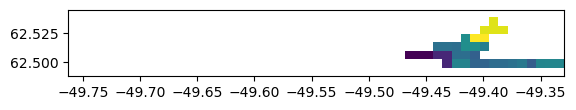

Coordinates:
    latitude   (lat) float64 64B 62.49 62.5 62.5 62.51 62.52 62.53 62.54 62.55
    longitude  (lon) float64 424B -49.76 -49.75 -49.75 ... -49.35 -49.34 -49.33

In [37]:
# now I assign the coordinates (lon lat) to the temp xarray array:
temp_coords = temp.assign_coords(
    longitude=("lon", lon),
    latitude=("lat", lat)
)

# write to netcdf file
temp_coords.to_netcdf("temp_with_coords.nc")


# plot to check
data = temp_coords["lake_surface_water_temperature"].isel(time = 225)
plt.imshow(np.flipud(data), extent=[lon[0], lon[-1], lat[0], lat[-1]]) # imshow transposes the matrix --> redo this using np.flipud()
plt.show()

temp_coords.coords


#### issue: It seems like the coordinate (lon and lat) are not correctly assigned, or at least it does not appear to me when I add the layer in QGIS. The same happended when I trie to plot it whith a basemap (and the shoreline polygon) in python to double check that its alright. 

However, it seems to work when I do this with the mask that has been provided:

In [38]:
###########################################################################################
# input parameters
###########################################################################################   

# lakes mask file 
maskfile = 'ESA_CCI_static_lake_mask_v2.0.1.nc'

# Id for lake kangaarsuup Taresua
lake_id = 300003969

# all three lake surface water temperature related vars
#varname = 'lake_surface_water_temperature' 
#varname = 'lswt_uncertainty'
#varname = 'lswt_quality_level'
#varname = 'lake_ice_cover_flag'
varname = 'lake_ice_cover_class'


# defining the period of time in string format: YYYY-MM-DD
# dates values must be between 1992-09-26 and 2020-12-31

mindate = '2018-01-01'
maxdate = '2018-12-31'

# test if dates are in the temporal coverage

mindate = datetime.datetime.strptime(mindate, '%Y-%m-%d')
maxdate = datetime.datetime.strptime(maxdate, '%Y-%m-%d')
mindate = max([mindate, datetime.datetime(1992,9,26)])
maxdate = min([maxdate, datetime.datetime(2022,12,31)])


##################################################################################################
# create mask based on lake_id, source: https://rmets.onlinelibrary.wiley.com/doi/10.1002/gdj3.32
##################################################################################################
mask_nc = nc.Dataset(maskfile)

minx = []
maxx = []
miny = []
maxy = []

nc_var = mask_nc.variables["CCI_lakeid"]
shape =  nc_var.shape

step = int(np.ceil(shape[0] / 10))
steps = list(range(0, shape[0] + step, step))

i = steps[0]
for j in steps[1:]:
    mask = nc_var[i:j, :]
    mask_ind = np.where(mask == lake_id)

    if mask_ind[0].size > 0 or mask_ind[1].size > 0:
        minx.append(np.min(mask_ind[1][:]) - 1)
        maxx.append(np.max(mask_ind[1][:]) + 1)
        miny.append(np.min(mask_ind[0][:]) - 1 + i)
        maxy.append(np.max(mask_ind[0][:]) + 1 + i )
    del mask
    i = j

minx = np.min(minx)
maxx = np.max(maxx)
miny = np.min(miny)
maxy = np.max(maxy)

mask_lake =nc_var[miny : maxy + 1, minx : maxx + 1]
mask_lake[mask_lake != lake_id] = 0
mask_lake[mask_lake == lake_id] = 1


lon = mask_nc.variables['lon'][minx:maxx + 1]
lat = mask_nc.variables['lat'][miny:maxy + 1]

print(mask_nc)

mask_nc.close()

<class 'netCDF4.Dataset'>
root group (NETCDF4_CLASSIC data model, file format HDF5):
    title: ESA CCI LAKE mask v2 and distance to land for 2024 lakes
    summary: This dataset contains the distance to land and IDs for all the water pixels at 1km (1/120 deg) of the CCI LAKES v2.
    references: L.Carrea, O. Embury and C.J. Merchant - High-resolution datasets related to in-land water for limnology and remote sensing applications: distance-to-land, distance-to-water, water-body identifier and lake-centre co-ordinates - Geoscience Data Journal, 2 (2). pp. 83-97. ISSN 2049-6060 doi: https://doi.org/10.1002/gdj3.32
    project: ESA CCI LAKES
    institution: University of Reading
    contact: l.carrea@reading.ac.uk
    source: Globolakes-static_distance_to_land_Map-300m-P5Y-2005-ESACCI_WB-fv1.0.nc, Globolakes-static_water_bodies_IDs_Map-300m-P5Y-2005-ESACCI_WB-fv1.0.nc
    cdm_data_type: grid
    date_created: 2021-10-06T16:30:24Z
    Conventions: CF-1.6
    standard_name_vocabulary: NetC

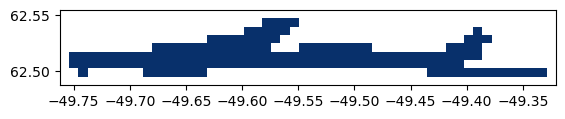

lon min:-49.76250076293945
lon max:-49.32083511352539


In [39]:
###################################################################
# Plot lake mask
###################################################################

plt.imshow(np.flipud(mask_lake), extent=[lon[0], lon[-1], lat[0], lat[-1]], cmap = 'Blues_r')
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.show()

print(f"lon min:{lon[0]}")
print(f"lon max:{lon[-1]}")

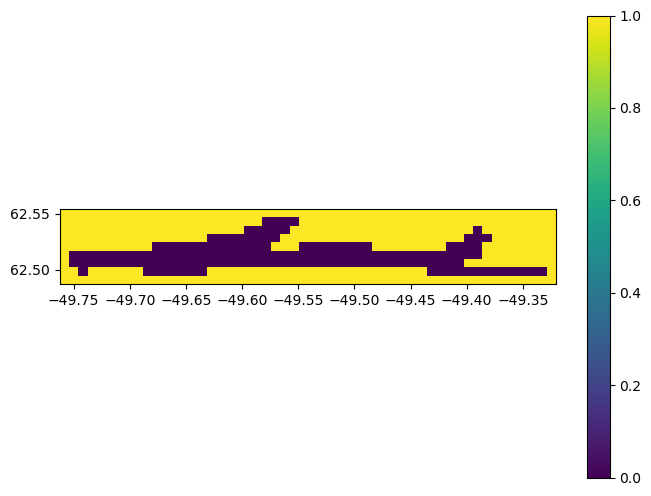

[[ True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True  True]
 [ True  True False  True  True  True  True  True  True False False False False False False False  True  True  True  True  True  True  True  True  True  True  True  True
   True  True  True  True  True  True  True  True  True  True  True  True False False False False False False False False False False False False False  True]
 [ True False False False False False False False False False False False False False False False False False False False False False False False False False False False
  False False False False False False False False False False False False False False False False  True  True  True  True  True  True  True  True  True  True]
 [ True False

In [42]:
# save the lon/lat to the lake_polygons folder (they are not saved anywhere else!)
np.savetxt("latidute_coords_lake_6.txt", lat)
np.savetxt("longitude_coords_lake_6.txt", lon)

mask_plot = np.array(mask_lake.mask)


import matplotlib.pyplot as plt

mask_plot = np.array(mask_lake.mask)

plt.figure(figsize=(8, 6))
plt.imshow(np.flipud(mask_plot), extent=[lon[0], lon[-1], lat[0], lat[-1]])
plt.colorbar()
plt.show()

### the lake in the plot is upside down
print(mask_plot)

### make the lon lat values:
mask_with_coords = xarray.DataArray(
    mask_lake,
    coords={
        "lat": lat,
        "lon": lon
    },
    dims=["lat", "lon"],
    name="lake_mask"
)

# then write it to disk:
mask_with_coords.to_netcdf(f"lake_6_mask_with_buffer_and_coords.nc") # this works, has been double checked in QGIS, EPSG is 4326


To the mask file I also assigned the coordinates, then have written it to the file `lake_6_mask_with_buffer_and_coords.nc`, and when using it in QGIS, it works and appears. 

I try plotting the mask with a satellite basemap to check whether it is on the right spot:


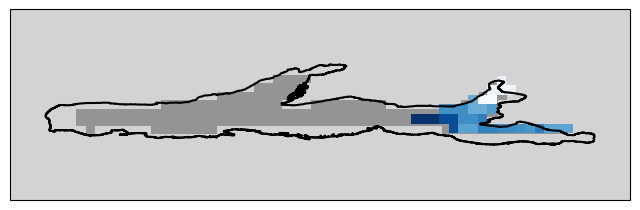

In [43]:
from cartopy import crs as ccrs, feature as cfeature

gdf = gpd.read_file("lake_6_shoreline.geojson")

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Background
ax.add_feature(cfeature.OCEAN, facecolor='white')
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Coastline
ax.coastlines(resolution='10m', linewidth=0.8)

gdf.boundary.plot(ax=ax, transform=ccrs.PlateCarree(), facecolor=None, edgecolor="black")

# # Lake mask
# ax.imshow(
#     np.flipud(mask_lake),
#     extent=[lon[0], lon[-1], lat[0], lat[-1]],
#     transform=ccrs.PlateCarree(),
#     cmap='Blues_r',
#     interpolation='nearest'
# )

ax.imshow(np.flipud(mask_lake), extent=[lon[0], lon[-1], lat[0], lat[-1]],
          transform=ccrs.PlateCarree(),
          cmap='grey', alpha = 0.3, 
          interpolation='nearest')

# Lake temp
ax.imshow(np.flipud(data),
          extent=[lon[0], lon[-1], lat[0], lat[-1]],
         transform=ccrs.PlateCarree(),
          cmap='Blues_r',
          interpolation='nearest'
         )

# Add a little geographic padding around the lake
padding = 0.05

ax.set_extent(
    [
        lon[0] - padding,
        lon[-1] + padding,
        lat[0] - padding,
        lat[-1] + padding
    ],
    crs=ccrs.PlateCarree()
)

plt.show()




#### convert one timestep to `.tif` file and check in QGIS

EPSG:4326


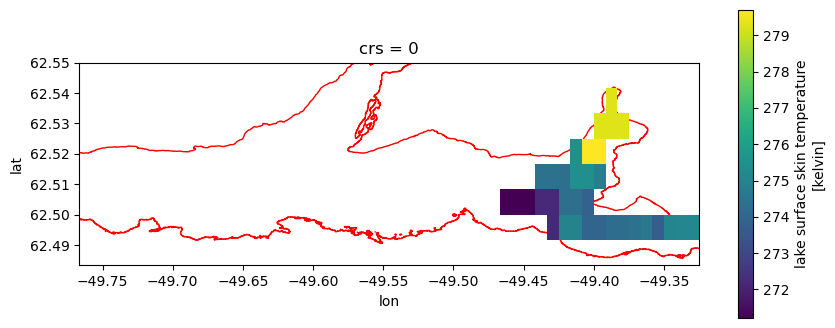

In [ ]:
import numpy as np
import xarray as xr
import rioxarray

# 1. Load NetCDF
nc_file = xr.open_dataset("lake_surface_temperature_2018.nc")

# 2. Load coordinates
lat = np.loadtxt(r"latidute_coords_lake_6.txt")
lon = np.loadtxt(r"longitude_coords_lake_6.txt")

# Remove buffer
lat = lat[0:8]
lon = lon[0:53]

# 3. Select the time slice
data_variable = nc_file["lake_surface_water_temperature"].isel(time=225)

# 4. Assign your coordinates
data_variable = data_variable.assign_coords(
    lat=("lat", lat),
    lon=("lon", lon)
)

# Make latitude decrease from north to south
data_variable = data_variable.sortby("lat", ascending=False)

# 5. Tell rioxarray which dimensions are spatial
data_variable = data_variable.rio.set_spatial_dims(
    x_dim="lon",
    y_dim="lat"
)

# 6. Set CRS
data_variable = data_variable.rio.write_crs("EPSG:4326")
print(data_variable.rio.crs)

# 7. Export
data_variable.rio.to_raster("output_file.tif")

# plot:
fig, ax = plt.subplots(figsize=(10, 4))

gdf = gdf.to_crs(data_variable.rio.crs)
gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=1)

data_variable.plot(
    ax=ax,
    x="lon",
    y="lat")

plt.show()

GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
